Phạm Hoàng Duy

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit,StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from utils import *
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import wandb

In [2]:
df = pd.read_csv('../../../data/creditcard.csv')

df = create_features(df)

scaler = StandardScaler()
df[['_log_amount']] = scaler.fit_transform(df[['_log_amount']])
df['hour_sin'] = np.sin(2 * np.pi * df['Hour_from_start_mod24']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour_from_start_mod24']/24)
df['time_diff'] = df['Time'].diff().fillna(0)
threshold = df['Amount'].quantile(0.95)  
df['is_high_amount'] = (df['Amount'] > threshold).astype(int)
df['is_rapid_transaction'] = (df['time_diff'] < 60).astype(int)
features = df.drop(['Time','Amount','Class','Hour_from_start_mod24'], axis=1).columns.tolist()
X = df[features]
y = df['Class']

X_train, y_train, X_val, y_val, X_test, y_test = split_data(df, features, 'Class')
df.head()

X_train: (181584, 36) y_train: (181584,)
X_val: (45396, 36) y_val: (45396,)
X_test: (56746, 36) y_test: (56746,)
Fraud rate in train: 0.001910961318177813
Fraud rate in test: 0.0013040566735981391


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,Class,_log_amount,Hour_from_start_mod24,is_night_proxy,is_business_hours_proxy,hour_sin,hour_cos,time_diff,is_high_amount,is_rapid_transaction
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0,1.123062,0,1,0,0.0,1.0,0.0,0,1
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0,-1.115298,0,1,0,0.0,1.0,0.0,0,1
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0,1.680981,0,1,0,0.0,1.0,1.0,1,1
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0,1.008128,0,1,0,0.0,1.0,0.0,0,1
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0,0.669117,0,1,0,0.0,1.0,1.0,0,1


In [3]:

X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

In [4]:
rf_model = RandomForestClassifier(
    n_estimators=700,
    max_depth=None,
    min_samples_split=7,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_model.fit(X_train, y_train)

p_val_rf = rf_model.predict_proba(X_val)[:, 1]

In [5]:
pos, neg = int((y_train==1).sum()), int((y_train==0).sum())

xgb_model = XGBClassifier(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.6,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    min_child_weight = 3,
    tree_method="hist",
    scale_pos_weight=neg/max(pos, 1),
    eval_metric='aucpr',
    random_state=42,
    gamma=1.0
)

xgb_model.fit(X_train, y_train)

p_val_xgb = xgb_model.predict_proba(X_val)[:, 1]


In [6]:
p_val_blend = 0.2 * p_val_rf + 0.8 * p_val_xgb

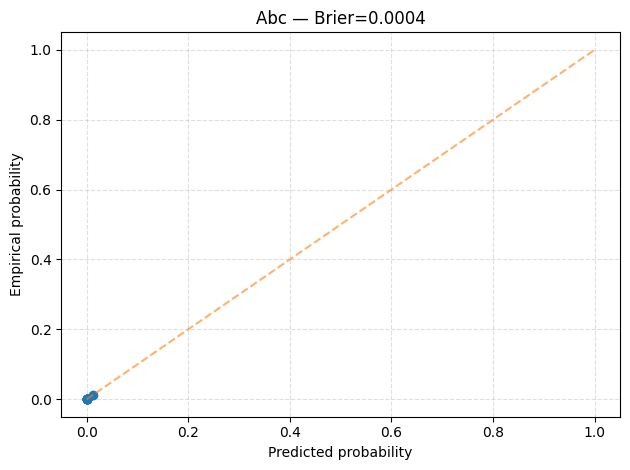

In [7]:
reliability_plot(y_val, p_val_blend, "Abc")

In [8]:
rs = []

rs.append({
    "model": "RF val",
    **log_eval(y_val, p_val_rf)  
})

rs.append({
    "model": "XGB val",
    **log_eval(y_val, p_val_xgb)  
})

rs.append({
    "model": "RF + XGB val",
    **log_eval(y_val, p_val_blend)  
})

val_df = pd.DataFrame(rs)
val_df

,model,threshold,Cost,ROC_AUC,PR_AUC,debiased_ece,adaptive_ece,Brier
0,RF val,0.032,2330.0,0.975765,0.762081,0.000632,0.000351,0.000396
1,XGB val,0.149,2320.0,0.987909,0.792648,0.000348,0.000276,0.000440
2,RF + XGB val,0.016,2270.0,0.985915,0.773154,0.000210,0.000222,0.000404


In [9]:
eval = []

for n in np.linspace(0,1,11):

    eval.append({
        "model": "RF + XGB val",
        **evaluate(y_val, p_val_blend, thr = n) 
    })

eval_df = pd.DataFrame(eval)
eval_df

,model,threshold,precision,recall,f1,roc_auc,auprc,brier,tp,fp,fn,tn
0,RF + XGB val,0.0,0.001145,1.000000,0.002288,0.985915,0.773154,0.000404,52,45344,0,0
1,RF + XGB val,0.1,0.602941,0.788462,0.683333,0.985915,0.773154,0.000404,41,27,11,45317
2,RF + XGB val,0.2,0.655738,0.769231,0.707965,0.985915,0.773154,0.000404,40,21,12,45323
3,RF + XGB val,0.3,0.727273,0.769231,0.747664,0.985915,0.773154,0.000404,40,15,12,45329
4,RF + XGB val,0.4,0.769231,0.769231,0.769231,0.985915,0.773154,0.000404,40,12,12,45332
5,RF + XGB val,0.5,0.812500,0.750000,0.780000,0.985915,0.773154,0.000404,39,9,13,45335
6,RF + XGB val,0.6,0.866667,0.750000,0.804124,0.985915,0.773154,0.000404,39,6,13,45338
7,RF + XGB val,0.7,0.928571,0.750000,0.829787,0.985915,0.773154,0.000404,39,3,13,45341
8,RF + XGB val,0.8,0.951220,0.750000,0.838710,0.985915,0.773154,0.000404,39,2,13,45342
9,RF + XGB val,0.9,0.945946,0.673077,0.786517,0.985915,0.773154,0.000404,35,2,17,45342


In [10]:
best_thr = 0.7

In [ ]:
rf_model.fit(X_full, y_full)
xgb_model.fit(X_full, y_full)

p_test_rf = rf_model.predict_proba(X_test)[:, 1]
p_test_xgb = xgb_model.predict_proba(X_test)[:, 1]

p_test_blend = 0.2 * p_test_rf + 0.8 * p_test_xgb

In [12]:
df_test_blend = pd.DataFrame([log_eval(y_test,p_test_blend, best_thr)])
df_test_blend

,threshold,Cost,Precision,Recall,F1,ROC_AUC,PR_AUC,debiased_ece,adaptive_ece,Brier
0,0.7,3635.0,0.888889,0.756757,0.817518,0.986497,0.803572,0.000191,0.000126,0.000418


In [13]:
df_test_blend = pd.DataFrame([evaluate(y_test,p_test_blend, best_thr)])
df_test_blend

,threshold,precision,recall,f1,roc_auc,auprc,brier,tp,fp,fn,tn
0,0.7,0.888889,0.756757,0.817518,0.986497,0.803572,0.000418,56,7,18,56665


In [16]:
import json

config = {
    "weights": {
        "rf": 0.2,
        "xgb": 0.8
    },
    "threshold": 0.7
}
with open("../../../artifacts/ensemble_rf_xgb_config.json", "w") as f:
    json.dump(config, f)
joblib.dump(xgb_model, "../../../artifacts/xgb_model_in_ensemble.joblib")

['../../../artifacts/xgb_model_in_ensemble.joblib']